# Music Classification : Evaluate & Improve your Models  

# Lab 2 : Improve your model with Feature Engineering

## Step 0 : Import necessary libraries

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import cross_val_score

## Step 1 :  Import prediction results of lab 1

In [2]:
# Load the Excel file
df = pd.read_excel('predicted_vs_actual.xlsx', sheet_name=None)
df

{'Decision Tree':      Actual Values  Predicted Values (Decision Tree)
 0                1                                 1
 1                0                                 0
 2                1                                 1
 3                0                                 0
 4                1                                 1
 ..             ...                               ...
 395              0                                 0
 396              1                                 1
 397              1                                 1
 398              0                                 1
 399              0                                 0
 
 [400 rows x 2 columns],
 'Random Forest':      Actual Values  Predicted Values (Random Forest)
 0                1                                 1
 1                0                                 0
 2                1                                 1
 3                0                                 0
 4                1  

In [3]:
# Load the Excel file
df_KNN = pd.read_excel('predicted_vs_actual.xlsx', sheet_name="KNN")
df_KNN

,Actual Values,Predicted Values (KNN)
0,1,1
1,0,0
2,1,1
3,0,0
4,1,0
...,...,...
395,0,0
396,1,0
397,1,1
398,0,1


In [4]:
# Initialize dictionaries to store metrics for each algorithm
metrics = {'Algorithm': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Calculate metrics for each algorithm
for algorithm, data in df.items():
    actual_values = data['Actual Values']
    predicted_values = data[f'Predicted Values ({algorithm})']
    
    metrics['Algorithm'].append(algorithm)
    metrics['Accuracy'].append(accuracy_score(actual_values, predicted_values))
    metrics['Precision'].append(precision_score(actual_values, predicted_values))
    metrics['Recall'].append(recall_score(actual_values, predicted_values))
    metrics['F1 Score'].append(f1_score(actual_values, predicted_values))

# Create DataFrame
results_df = pd.DataFrame(metrics)

# Find the best algorithm based on accuracy
best_algorithm = results_df.loc[results_df['Accuracy'].idxmax()]


# Print the best algorithm
print(f"\n### Best Algorithm based on Accuracy : {best_algorithm['Algorithm']}")
results_df



### Best Algorithm based on Accuracy : Random Forest


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.9375,0.940000,0.935323,0.937656
1,Random Forest,0.9650,0.947368,0.985075,0.965854
2,Naive Bayes,0.9450,0.928230,0.965174,0.946341
3,KNN,0.8175,0.851648,0.771144,0.809399


## Step 2 : Load Spotify Dataset From Csv File 

In [5]:
data_df = pd.read_csv('./SpotifyDataset_WithNA.csv' , index_col=0)
data_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
data_df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [7]:
selected_genres =  ['happy','sad']
data = data_df[data_df['track_genre'].isin(selected_genres)].copy()
data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
46000,6iBL6TOzsO75Yz0cG1MO0o,The Prophet,Wanna Play?,Wanna Play?,65,201451,False,0.569,0.996,5,-0.450,1,0.2240,0.198000,0.011400,0.7070,0.461,100.020,3,happy
46001,2d9EgBM9F09IkEG8t9T6L8,Darren Styles;TNT,DLMD,DLMD,59,160212,False,0.487,0.990,0,-2.282,1,0.0940,0.000595,0.843000,0.3310,0.161,160.046,4,happy
46002,6RvTtRyn7zVayLUWAJxd5Z,S3RL,Hentai,Hentai,55,185830,False,0.496,0.760,4,-4.281,1,0.3930,0.000799,0.002850,0.3680,0.422,174.944,4,happy
46003,0L0DM33NAe6PjQ1BB4cEjJ,Darren Styles,Us Against The World,Us Against The World,62,271058,False,0.531,0.896,1,-3.297,0,0.1070,0.031600,0.007230,0.0297,0.340,169.955,4,happy
46004,4tV6ku4jEYw9L5gZuNpCbP,Gammer;Darren Styles,DYSYLM,DYSYLM,57,176051,False,0.532,0.878,7,-3.933,0,0.2150,0.010200,0.201000,0.1690,0.385,169.962,4,happy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,4DqNBM2oUr5R87cUd2E3P6,Josh A,LONELY VIBES (Deluxe),PTSD,41,121867,False,0.644,0.637,7,-7.922,1,0.0898,0.382000,0.000000,0.1410,0.216,81.479,4,sad
94996,6HdrRVMieDZtv0vldfZxqg,Rarin,Day Ones,Day Ones,47,134913,True,0.739,0.639,9,-8.636,1,0.2530,0.119000,0.000000,0.1190,0.482,143.044,4,sad
94997,6hzTeCA93yeY8WZE0kW3ui,Powfu,some boring love stories pt 5,clash of the titans,42,110000,False,0.727,0.419,1,-8.334,1,0.1870,0.595000,0.000000,0.1120,0.751,158.344,4,sad
94998,7sFRIgzKlKRSfBDWUvtpwU,LoveJSan,Saddest Popstar to Live,I Got You Flowers!,49,154000,True,0.598,0.540,7,-6.199,1,0.0363,0.050400,0.000144,0.2110,0.244,140.130,4,sad


## Step 4 : Feature Engineering - Data Preprocessing

### 1) Handling Missing values Version 1

In [8]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [9]:
data.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            9
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             7
tempo               0
time_signature      0
track_genre         0
dtype: int64

Number of rows containing missing values before handling them: 16
Number of rows containing missing values after handling them: 0


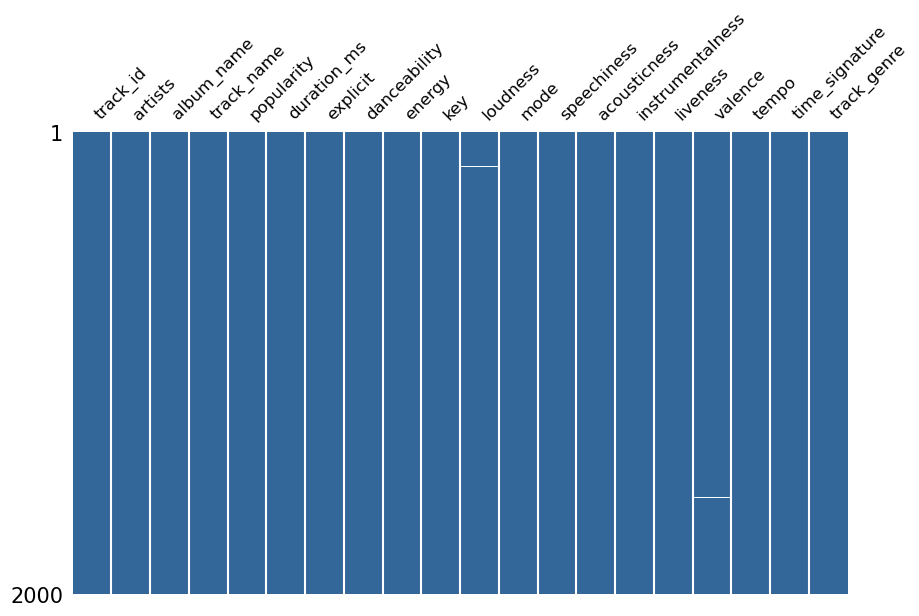

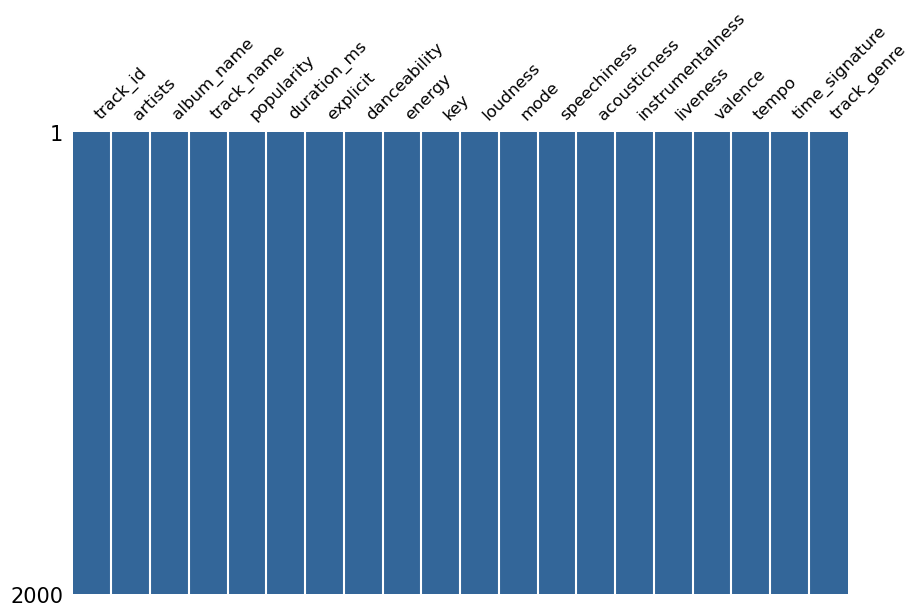

In [10]:

# Import necessary libraries
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# Get the number of rows containing missing values before handling them
num_missing_before = data.isnull().any(axis=1).sum()

# Visualize missing values in the dataset before handling them
msno.matrix(data, figsize=(10, 6), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))

# Iterate through each row to handle missing values
for index, row in data.iterrows():
    if row.isnull().any():
        # Check if the row has only one missing value
        if row.isnull().sum() == 1:
            # Check if the column is categorical or numerical

            numerical_cols = data.select_dtypes(include=np.number).columns
            missing_col = row[row.isnull()].index[0]  # Get the column with missing value
            
            if missing_col in numerical_cols:
                # For numerical variables, replace missing value with mean
                data.loc[index, missing_col] = data[missing_col].astype(float).mean()  # Replace missing value with mean

# Drop rows with more than one missing value
data.dropna(thresh=data.shape[1]-1, inplace=True)

# Get the number of rows containing missing values after handling them
num_missing_after = data.isnull().any(axis=1).sum()

# Print the number of rows containing missing values before and after processing
print(f"Number of rows containing missing values before handling them: {num_missing_before}")
print(f"Number of rows containing missing values after handling them: {num_missing_after}")

# Visualize missing values in the dataset after handling them
msno.matrix(data, figsize=(10, 6), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))

# Show plots
plt.show()




#### Handling Missing values Version 2

Number of rows containing missing values before handling them: 16
Number of rows containing missing values after handling them: 0


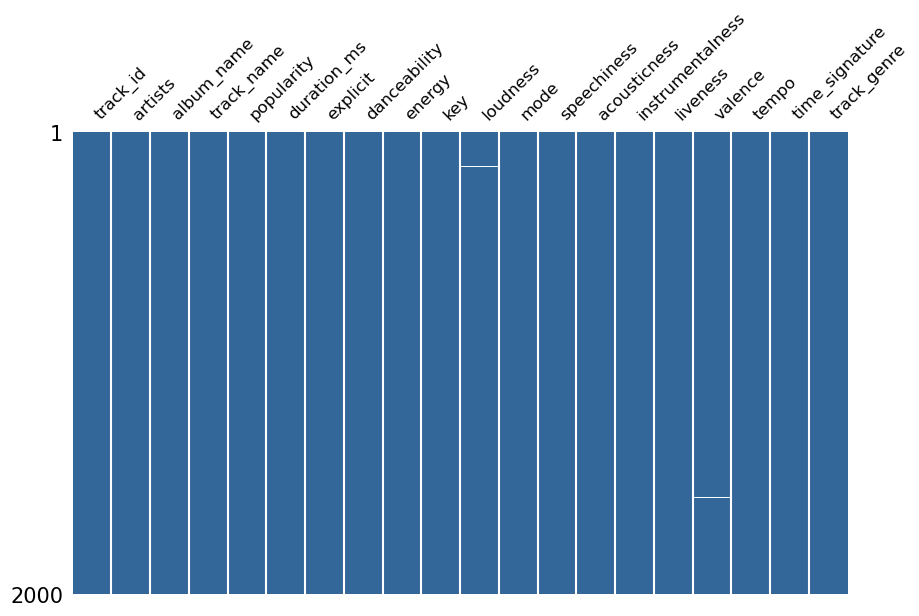

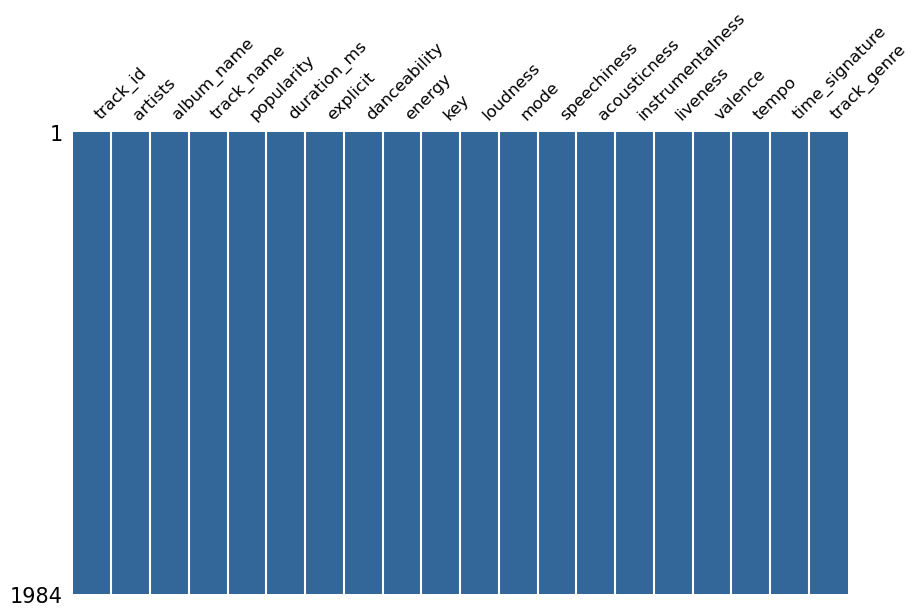

In [25]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# Get the number of rows containing missing values before handling them
num_missing_before = data.isnull().any(axis=1).sum()

# Visualize missing values in the dataset before handling them
msno.matrix(data, figsize=(10, 6), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))

# Drop rows containing at least one missing value
data.dropna(inplace=True)

# Get the number of rows containing missing values after handling them
num_missing_after = data.isnull().any(axis=1).sum()

# Print the number of rows containing missing values before and after processing
print(f"Number of rows containing missing values before handling them: {num_missing_before}")
print(f"Number of rows containing missing values after handling them: {num_missing_after}")

# Visualize missing values in the dataset after handling them
msno.matrix(data, figsize=(10, 6), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))

# Show plots
plt.show()



### 2) Feature Nomarlizing

#### Split Dataset before Normalization

In [32]:
# Import Data without Missing values to work on for Improvements 

data_df = pd.read_csv("SpotifyDataset.csv" , index_col=0)
selected_genres =  ['happy','sad']
data = data_df[data_df['track_genre'].isin(selected_genres)].copy()

In [35]:
musical_features = [
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

X = data[musical_features] 
y = data['track_genre']  # Target variable "track genre"

In [36]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
46968,0.548,0.9990,0,-4.937,1,0.0947,0.050100,0.01280,0.9780,0.0878,145.000,4
46240,0.725,0.8920,7,-13.914,1,0.2880,0.351000,0.01550,0.1770,0.1760,170.060,4
46819,0.903,0.9800,11,-5.024,1,0.2090,0.000977,0.13000,0.2150,0.3300,140.026,4
46692,0.392,0.9510,11,-3.941,0,0.0640,0.184000,0.00128,0.0959,0.3940,151.998,4
46420,0.670,0.9900,10,-3.988,0,0.0734,0.001560,0.83700,0.4980,0.2870,92.484,4
...,...,...,...,...,...,...,...,...,...,...,...,...
94130,0.708,0.2130,7,-8.266,1,0.0396,0.924000,0.00118,0.1110,0.1090,80.020,4
94294,0.782,0.5200,7,-9.338,0,0.1710,0.174000,0.00000,0.0747,0.4950,113.958,4
46860,0.607,0.8920,2,-6.939,1,0.0374,0.112000,0.94900,0.1200,0.0973,95.491,4
94459,0.703,0.5520,11,-10.288,1,0.1950,0.835000,0.10100,0.5690,0.6090,176.132,4


#### Use Stander Scaler or MinMaxScaler 

In [38]:
# Preprocess numerical features (scaling)
scaler = StandardScaler() # this applies z-score normalization

X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include=['int64', 'float64'])) #scaling the training set

X_test_scaled = scaler.transform(X_test.select_dtypes(include=['int64', 'float64']))#scaling the test set


In [39]:
X_train_scaled

array([[-0.54238866,  1.15723938, -1.57103891, ..., -1.26382298,
         0.2645549 ,  0.09395338],
       [ 0.75221285,  0.76229847,  0.41268553, ..., -0.87461867,
         1.01314017,  0.09395338],
       [ 2.05412849,  1.08710968,  1.54624236, ..., -0.19505557,
         0.11597297,  0.09395338],
       ...,
       [-0.11085483,  0.76229847, -1.0042605 , ..., -1.22190188,
        -1.21436402,  0.09395338],
       [ 0.59130193, -0.49265395,  1.54624236, ...,  1.03610095,
         1.19452125,  0.09395338],
       [ 1.40317067, -2.16580081,  0.41268553, ...,  2.19665351,
        -0.78170205,  3.67312991]])

### 3) Encoding Categorical variables 

In [47]:
np.array(y_train)

array(['happy', 'happy', 'happy', ..., 'happy', 'sad', 'sad'],
      dtype=object)

In [58]:
# Preprocess categorical features 
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [59]:
y_test_encoded

array([1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,

### 4) Outliers Detection with BoxPlot

In [61]:
X_Train_df = pd.DataFrame(X_train_scaled)
X_Train_df

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.542389,1.157239,-1.571039,0.669627,0.829315,-0.274614,-0.689366,-0.576357,4.166287,-1.263823,0.264555,0.093953
1,0.752213,0.762298,0.412686,-1.370339,0.829315,1.476233,0.264117,-0.567511,-0.284662,-0.874619,1.013140,0.093953
2,2.054128,1.087110,1.546242,0.649856,0.829315,0.760678,-0.845025,-0.192404,-0.073506,-0.195056,0.115973,0.093953
3,-1.683393,0.980070,1.546242,0.895961,-1.205814,-0.552684,-0.265068,-0.614097,-0.735314,0.087360,0.473597,0.093953
4,0.349936,1.124020,1.262853,0.885281,-1.205814,-0.467542,-0.843178,2.123761,1.499052,-0.384804,-1.304188,0.093953
...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0.627873,-1.743915,0.412686,-0.086867,0.829315,-0.773691,2.079821,-0.614424,-0.651407,-1.170273,-1.676509,0.093953
1596,1.169118,-0.610767,0.412686,-0.330473,-1.205814,0.416486,-0.296755,-0.618290,-0.853117,0.533048,-0.662723,0.093953
1597,-0.110855,0.762298,-1.004261,0.214685,0.829315,-0.793618,-0.493219,2.490678,-0.601397,-1.221902,-1.214364,0.093953
1598,0.591302,-0.492654,1.546242,-0.546354,0.829315,0.633870,1.797801,-0.287409,1.893580,1.036101,1.194521,0.093953


<Axes: >

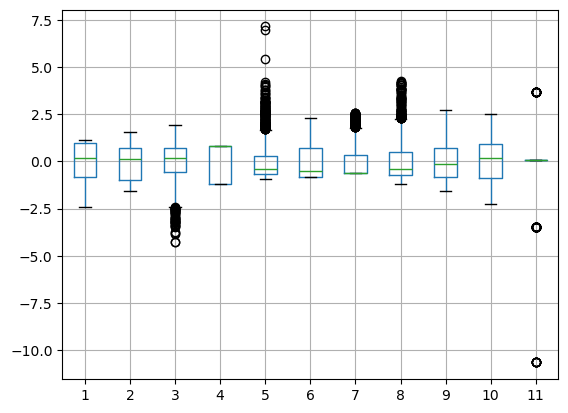

In [64]:
X_Train_df.boxplot(column=[1, 2, 3, 4, 5 , 6 , 7, 8, 9, 10, 11])  

# Lab 3 : Hyperparameters Tuning : Random Forest Classifier 

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint
import random


### 1) Set Up a Base Random Forest Classifier

In [77]:
# Define the knn classifier
RF = RandomForestClassifier() 

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Train the Random Forest classifier
RF.fit(X_train_scaled, y_train_encoded)

# Make predictions on the test set
y_pred = RF.predict(X_test_scaled)

# Evaluate the classifier
accuracy = accuracy_score(y_test_encoded, y_pred)

# Compute precision
precision = precision_score(y_test_encoded, y_pred)
# Compute recall
recall = recall_score(y_test_encoded, y_pred)
# Compute F1 score
f1 = f1_score(y_test_encoded, y_pred)

# Print evaluation metrics
print("RF Classifier Performance:")
print(f"Accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1_score: {f1}")

RF Classifier Performance:
Accuracy: 0.97
precision: 0.9521531100478469
recall: 0.9900497512437811
f1_score: 0.9707317073170731


In [79]:
#Old Metrics
results_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.9375,0.940000,0.935323,0.937656
1,Random Forest,0.9650,0.947368,0.985075,0.965854
2,Naive Bayes,0.9450,0.928230,0.965174,0.946341
3,KNN,0.8175,0.851648,0.771144,0.809399


### 2) Quick Hyperparameter Tuning : Random Search 

#### Without Iterations Log

In [82]:
# Without Iterations Log
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': [None, 'sqrt', 'log2']
}


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train_encoded)

print("Best parameters from RandomizedSearchCV:\n", random_search.best_params_)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
🔁 RandomizedSearchCV Results:
Best parameters from RandomizedSearchCV:
 {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 413}


#### With Iterations Log

In [85]:
from sklearn.model_selection import cross_val_score
from scipy.stats import randint
import random
from sklearn.ensemble import RandomForestClassifier

# Define parameter distribution
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': [None , 'sqrt', 'log2']
}

# Create list of randomly sampled parameter sets
n_iter = 20
random_param_sets = []
for _ in range(n_iter):
    params = {
        'n_estimators': param_dist['n_estimators'].rvs(),
        'max_depth': random.choice(param_dist['max_depth']),
        'min_samples_split': param_dist['min_samples_split'].rvs(),
        'min_samples_leaf': param_dist['min_samples_leaf'].rvs(),
        'max_features': random.choice(param_dist['max_features']),
        'random_state': 42
    }
    random_param_sets.append(params)

# Evaluate each param set manually and print live results
results = []

print("🔄 Starting manual random search...\n")
for i, params in enumerate(random_param_sets, 1):
    rf = RandomForestClassifier(**params)
    scores = cross_val_score(rf, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    results.append((params, mean_score))
    print(f"Iteration {i}/{n_iter} - Score: {mean_score:.4f} - Params: {params}")


🔄 Starting manual random search...

Iteration 1/20 - Score: 0.9706 - Params: {'n_estimators': 131, 'max_depth': None, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None, 'random_state': 42}
Iteration 2/20 - Score: 0.9656 - Params: {'n_estimators': 243, 'max_depth': None, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'random_state': 42}
Iteration 3/20 - Score: 0.9675 - Params: {'n_estimators': 396, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'random_state': 42}
Iteration 4/20 - Score: 0.9738 - Params: {'n_estimators': 391, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 42}
Iteration 5/20 - Score: 0.9725 - Params: {'n_estimators': 270, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'random_state': 42}
Iteration 6/20 - Score: 0.9713 - Params: {'n_estimators': 362, 'max_depth': 15, 'min_samples_split': 8, '

In [90]:
best_params, best_score = max(results, key=lambda x: x[1])
print("\n🏆 Best Random Search Parameters Found:")
print(best_params)
print(f"\n✅ Best Random Search Score: {best_score:.4f}")


🏆 Best Random Search Parameters Found:
{'n_estimators': 391, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 42}

✅ Best Random Search Score: 0.9738


### 3) Grid Search ( Fine-Tuning Around the Best Random Search Params )

In [96]:
grid_params = {
    'n_estimators': [best_params['n_estimators'] - 50,
                     best_params['n_estimators'],
                     best_params['n_estimators'] + 50],
    'max_depth': [best_params['max_depth']],
    'min_samples_split': [best_params['min_samples_split'] - 1,
                          best_params['min_samples_split'],
                          best_params['min_samples_split'] + 1],
    'min_samples_leaf': [best_params['min_samples_leaf']],
    'max_features': [best_params['max_features']]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=grid_params,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_encoded)
print("Best parameters from GridSearchCV:\n", grid_search.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters from GridSearchCV:
 {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 341}


In [98]:
print("Best Score from GridSearchCV:\n", grid_search.best_score_)

Best Score from GridSearchCV:
 0.9737500000000001


### 4) Cross Validation Score Using K-Fold

In [101]:
# Get the best model
best_rf = grid_search.best_estimator_

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_rf, X_train_scaled, y_train_encoded, cv=kfold)

print("K-Fold Cross-Validation Scores:", cv_scores)
print("Average CV Score on Train Set:", np.mean(cv_scores))


K-Fold Cross-Validation Scores: [0.990625 0.96875  0.971875 0.9625   0.96875 ]
Average CV Score on Train Set: 0.9725000000000001


In [99]:
# Get the best model
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test_scaled) 

# Evaluate the best model on the test set
accuracy = best_model.score(X_test_scaled, y_test_encoded) 
print("Accuracy on Test Set:", accuracy)


Accuracy on Test Set: 0.965


Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Accuracy on Test Set: 0.9482758620689655
